<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/Copia_di_Cyberr_Sicurty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Installazione delle librerie
# scikit-learn è una dipendenza utile per varie funzionalità, spesso presente su Colab ma la includiamo per sicurezza.
!pip install scikit-learn
# gym-idsgame è l'ambiente principale. Usiamo --no-deps per evitare che installi dipendenze obsolete di gym.
!pip install --no-deps gym-idsgame

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.8/452.8 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gym-idsgame: filename=gym_idsgame-1.0.13-py3-none-any.whl size=969685 sha256=1dd406960dea0a0148e061e6f4083ccfb662e45ea92c5e7b8b193c34b05a4ecc
  Stored in directory: /root/.cache/pip/wheels/01/d9/e1/a505d26b5a11360285f1052d34b792ae263589fafdad70ba0d
Successfully built gym-idsgame


In [ ]:
# 2. Importazioni essenziali e patch per gym-idsgame
import numpy as np
from gym_idsgame.envs import IdsGameRandomAttackV21Env, IdsGameMaximalAttackV21Env

# Patch per risolvere un bug nella libreria gym-idsgame
import gym_idsgame.envs.util.idsgame_util as _idsgame_util
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as _random_bot
import gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent as _maximal_bot

# Verifica e applica la patch se non già presente
if not hasattr(_random_bot, 'idsgame_util'):
    _random_bot.idsgame_util = _idsgame_util
    print("Patch applicata: random_attack_bot_agent")

if not hasattr(_maximal_bot, 'idsgame_util'):
    _maximal_bot.idsgame_util = _idsgame_util
    print("Patch applicata: attack_maximal_value_bot_agent")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Patch applicata: random_attack_bot_agent
Patch applicata: attack_maximal_value_bot_agent


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import numpy as np

class DefenderWrapper:
    """
    Wrapper che adatta gym-idsgame per il single-agent (difensore).
    L'attaccante è gestito dal bot interno dell'ambiente.
    """
    def __init__(self, env):
        self.env = env
        self.action_space = env.defender_action_space

    def reset(self):
        obs = self.env.reset()
        # reset() restituisce (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]
        return obs.flatten()

    def step(self, action):
        # Passiamo un'azione qualsiasi (!= -1) per attivare il bot attaccante
        attacker_action = self.env.attacker_action_space.sample()
        res = self.env.step((attacker_action, action))

        obs, reward, done = res[0], res[1], res[2]
        info = res[3] if len(res) > 3 else {}

        # Estraiamo solo la parte del difensore
        if isinstance(obs, tuple):
            obs = obs[1]
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs.flatten(), reward, done, info

In [ ]:
# --- Maximal Attack ---
raw_env_max = IdsGameMaximalAttackV21Env()
env_max = DefenderWrapper(raw_env_max)

obs = env_max.reset()
print(f"Osservazione iniziale: shape={obs.shape}, dtype={obs.dtype}")
print(f"Numero azioni difensore: {env_max.action_space.n}")

for i in range(5):
    action = env_max.action_space.sample()
    obs, reward, done, info = env_max.step(action)
    print(f"  Step {i+1}: reward={reward}, done={done}")
    if done:
        break

print("\nMaximal Attack: OK!")

Osservazione iniziale: shape=(20,), dtype=float64
Numero azioni difensore: 20
  Step 1: reward=0, done=False
  Step 2: reward=0, done=False
  Step 3: reward=0, done=False
  Step 4: reward=0, done=False
  Step 5: reward=0, done=False

Maximal Attack: OK!


In [ ]:
def random_baseline(env, n_episodes=500, max_steps=100):
    wins, losses = 0, 0
    total_rewards = []

    for _ in range(n_episodes):
        obs = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < max_steps:
            action = env.action_space.sample()
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            steps += 1

        total_rewards.append(ep_reward)
        if ep_reward > 0:
            wins += 1
        elif ep_reward < 0:
            losses += 1

    print(f"Episodi: {n_episodes}")
    print(f"Vittorie difensore: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"Vittorie attaccante: {losses} ({losses/n_episodes*100:.1f}%)")
    print(f"Reward medio: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

print("=== Baseline Random Attack ===")
env_ra = DefenderWrapper(IdsGameRandomAttackV21Env())
random_baseline(env_ra)

print("\n=== Baseline Maximal Attack ===")
env_ma = DefenderWrapper(IdsGameMaximalAttackV21Env())
random_baseline(env_ma)

=== Baseline Random Attack ===
Episodi: 500
Vittorie difensore: 2 (0.4%)
Vittorie attaccante: 261 (52.2%)
Reward medio: -13.558 ± 12.983

=== Baseline Maximal Attack ===
Episodi: 500
Vittorie difensore: 0 (0.0%)
Vittorie attaccante: 333 (66.6%)
Reward medio: -17.314 ± 12.261


In [ ]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env

# Crea l'ambiente originale
raw_env_import = IdsGameRandomAttackV21Env()

# Applica il DefenderWrapper
env_ready = DefenderWrapper(raw_env_import)

print("Ambiente 'env_ready' importato e wrappato con successo!")
print(f"Spazio delle azioni del difensore: {env_ready.action_space}")

# Puoi ora resettare l'ambiente e iniziare a interagire con esso
initial_observation = env_ready.reset()
print(f"Osservazione iniziale (appiattita): {initial_observation.shape}")

Ambiente 'env_ready' importato e wrappato con successo!
Spazio delle azioni del difensore: Discrete(20)
Osservazione iniziale (appiattita): (20,)


## testiamo uno step

In [ ]:
action = env_ready.action_space.sample()
obs, reward, done, info = env_ready.step(action)

print(f"Azione scelta: {action}")
print(f"Obs shape: {obs.shape}")
print(f"Reward: {reward}")
print(f"Done: {done}")
print(f"Info: {info}")

Azione scelta: 9
Obs shape: (20,)
Reward: 0
Done: False
Info: {'moved': False}


##5 step consecutivi per verificare che il wrapper non si rompa

In [ ]:
obs = env_ready.reset()

for i in range(5):
    action = env_ready.action_space.sample()
    obs, reward, done, info = env_ready.step(action)

    print(f"Step {i+1}")
    print(f"  Azione: {action}")
    print(f"  Obs shape: {obs.shape}")
    print(f"  Reward: {reward}")
    print(f"  Done: {done}")
    print(f"  Info: {info}")

    if done:
        print("Episodio terminato")
        break

Step 1
  Azione: 8
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 2
  Azione: 0
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 3
  Azione: 13
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 4
  Azione: 0
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 5
  Azione: 12
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': True}


In [ ]:
obs = env_ready.reset()
print(f"Osservazione iniziale: shape={obs.shape}, dtype={obs.dtype}")
print(f"Numero azioni difensore: {env_ready.action_space.n}")


Osservazione iniziale: shape=(20,), dtype=float64
Numero azioni difensore: 20


##verifichiamo che i valori sono compatibili con un sarsa tabellare

In [ ]:
action = env_ready.action_space.sample()
obs, reward, done, info = env_ready.step(action)

print("obs:", obs)
print("reward:", reward)
print("done:", done)
print("info:", info)

obs: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 0. 0. 0. 0. 0.]
reward: 0
done: False
info: {'moved': False}


In [ ]:
print(np.unique(obs))

[0. 1. 2.]


In [ ]:
tuple(obs.astype(int))

(np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0))

In [ ]:
print(raw_env_max.observation_space)
print(type(raw_env_max.observation_space))

Box(0, 9, (1, 5), int32)
<class 'gym.spaces.box.Box'>


##codice completo sarsa

In [ ]:
class SarsaBoxAgent:
    """
    Agente SARSA per ambienti con vettore di osservazione.
    """
    def __init__(self, n_actions, n_states=100000, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha            # Learning rate
        self.gamma = gamma            # Discount factor
        self.epsilon = epsilon        # Epsilon per la politica epsilon-greedy
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table bidimensionale: 100.000 righe x n_actions colonne
        self.q_table = np.zeros((self.n_states, self.n_actions), dtype=np.float32)

    def obs_to_state_index(self, obs):
        """
        Converte l'osservazione in un indice intero valido [0, n_states - 1]
        prevenendo l'errore di Overflow.
        """
        flat_obs = np.array(obs, dtype=np.int64).flatten()

        # Mappatura deterministica tramite hash con modulo per restare nel range [0, self.n_states - 1]
        return abs(hash(flat_obs.tobytes())) % self.n_states

    def choose_action(self, state_idx):
        """
        Selezione dell'azione con politica Epsilon-Greedy.
        """
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)  # Esplorazione

        return np.argmax(self.q_table[state_idx, :])  # Sfruttamento

    def update(self, state_idx, action, reward, next_state_idx, next_action, done):
        """
        Regola di aggiornamento SARSA:
        Q(s, a) <- Q(s, a) + alpha * [r + gamma * Q(s', a') - Q(s, a)]
        """
        current_q = self.q_table[state_idx, action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * self.q_table[next_state_idx, next_action]

        self.q_table[state_idx, action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        """Riduzione graduale di epsilon ad ogni episodio."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


def train_sarsa_box(env, n_episodes=1000, alpha=0.1, gamma=0.95):
    """
    Funzione di addestramento SARSA.
    """
    n_actions = env.action_space.n
    agent = SarsaBoxAgent(n_actions=n_actions, alpha=alpha, gamma=gamma)

    rewards_history = []
    wins_history = []

    print(f"Q-Table creata con successo: {agent.q_table.shape} (stati x azioni)")
    print("Inizio addestramento SARSA...\n")

    for ep in range(1, n_episodes + 1):
        obs = env.reset()
        state_idx = agent.obs_to_state_index(obs)

        action = agent.choose_action(state_idx)
        total_reward = 0
        done = False

        while not done:
            next_obs, reward, done, info = env.step(action)
            next_state_idx = agent.obs_to_state_index(next_obs)

            next_action = agent.choose_action(next_state_idx)

            # Aggiornamento TD SARSA
            agent.update(state_idx, action, reward, next_state_idx, next_action, done)

            state_idx = next_state_idx
            action = next_action
            total_reward += reward

        agent.decay_epsilon()
        rewards_history.append(total_reward)
        wins_history.append(1 if total_reward > 0 else 0)

        if ep % 200 == 0 or ep == n_episodes:
            win_rate = np.mean(wins_history[-100:]) * 100
            mean_rew = np.mean(rewards_history[-100:])
            print(f"Episodio {ep}/{n_episodes} | Win Rate (ultimi 100): {win_rate:.1f}% | Reward Medio: {mean_rew:.2f} | Epsilon: {agent.epsilon:.3f}")

    return agent, rewards_history, wins_history

##Esecuzione nell'ambiente

In [ ]:
sarsa_agent, rewards, wins = train_sarsa_box(env_ready, n_episodes=1000)

Q-Table creata con successo: (100000, 20) (stati x azioni)
Inizio addestramento SARSA...

Episodio 200/1000 | Win Rate (ultimi 100): 1.0% | Reward Medio: -11.94 | Epsilon: 0.367
Episodio 400/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -11.44 | Epsilon: 0.135
Episodio 600/1000 | Win Rate (ultimi 100): 1.0% | Reward Medio: -14.01 | Epsilon: 0.049
Episodio 800/1000 | Win Rate (ultimi 100): 2.0% | Reward Medio: -12.19 | Epsilon: 0.018
Episodio 1000/1000 | Win Rate (ultimi 100): 1.0% | Reward Medio: -12.73 | Epsilon: 0.010


##grafici

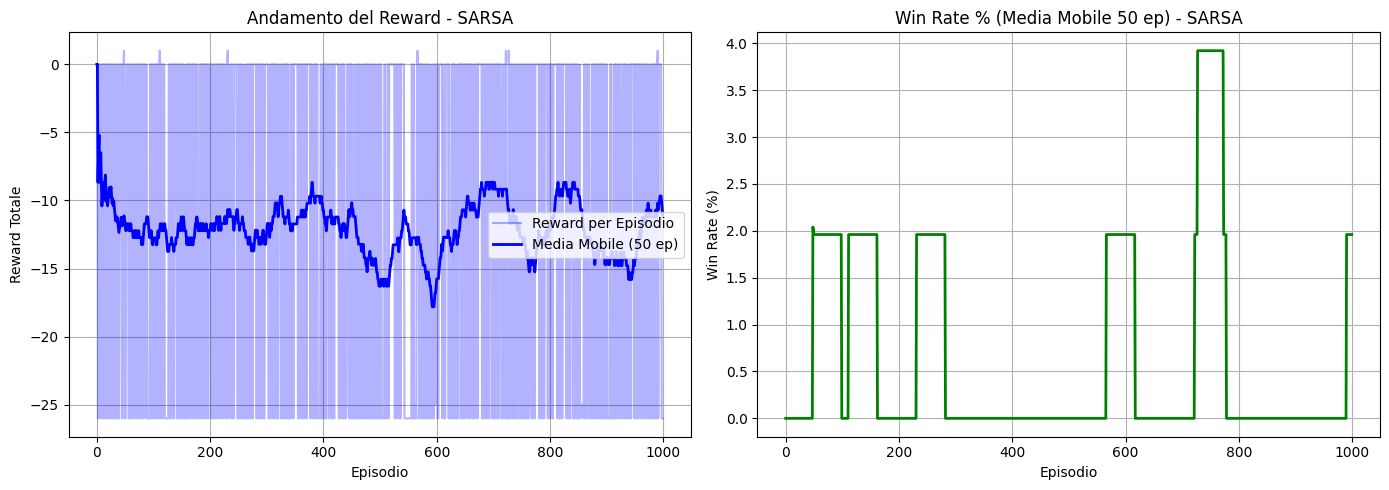

In [ ]:
import matplotlib.pyplot as plt

# Calcolo media mobile su finestra di 50 episodi
window = 50
smooth_rewards = [np.mean(rewards[max(0, i-window):i+1]) for i in range(len(rewards))]
smooth_wins = [np.mean(wins[max(0, i-window):i+1]) * 100 for i in range(len(wins))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico dei Reward
ax1.plot(rewards, alpha=0.3, color='blue', label='Reward per Episodio')
ax1.plot(smooth_rewards, color='blue', linewidth=2, label=f'Media Mobile ({window} ep)')
ax1.set_title('Andamento del Reward - SARSA')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Reward Totale')
ax1.grid(True)
ax1.legend()

# Grafico del Win Rate
ax2.plot(smooth_wins, color='green', linewidth=2)
ax2.set_title(f'Win Rate % (Media Mobile {window} ep) - SARSA')
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Win Rate (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

##Codice PyTorch per Agente DDQN

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# --- 1. ARCHITETTURA DELLA RETE NEURALE ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

# --- 2. REPLAY BUFFER ---
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (
            torch.tensor(np.array(state), dtype=torch.float32),
            torch.tensor(action, dtype=torch.long),
            torch.tensor(reward, dtype=torch.float32),
            torch.tensor(np.array(next_state), dtype=torch.float32),
            torch.tensor(done, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# --- 3. AGENTE DDQN ---
class DDQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, batch_size=64):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Rete principale e Rete Target
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(capacity=20000)

        # Parametri Epsilon-Greedy
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
        return torch.argmax(q_values, dim=1).item()

    def update(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = states.to(self.device)
        actions = actions.unsqueeze(1).to(self.device)
        rewards = rewards.unsqueeze(1).to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.unsqueeze(1).to(self.device)

        # Q-value corrente
        current_q = self.policy_net(states).gather(1, actions)

        # DDQN Target: la rete principale sceglie l'azione, la target net ne valuta il Q-value
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q

        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##loop di addestramento

In [ ]:
def train_ddqn(env, n_episodes=1000, target_update_freq=10):
    state_dim = env.reset().shape[0]
    action_dim = env.action_space.n
    agent = DDQNAgent(state_dim=state_dim, action_dim=action_dim)

    rewards_history = []
    wins_history = []

    print(f"Dispositivo utilizzato: {agent.device}")
    print(f"Stato dim: {state_dim} | Azioni: {action_dim}")
    print("Inizio addestramento DDQN...\n")

    for ep in range(1, n_episodes + 1):
        obs = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.choose_action(obs)
            next_obs, reward, done, info = env.step(action)

            agent.memory.push(obs, action, reward, next_obs, done)
            agent.update()

            obs = next_obs
            total_reward += reward

        agent.decay_epsilon()

        if ep % target_update_freq == 0:
            agent.update_target_network()

        rewards_history.append(total_reward)
        wins_history.append(1 if total_reward > 0 else 0)

        if ep % 100 == 0 or ep == n_episodes:
            win_rate = np.mean(wins_history[-100:]) * 100
            mean_rew = np.mean(rewards_history[-100:])
            print(f"Episodio {ep}/{n_episodes} | Win Rate (ultimi 100): {win_rate:.1f}% | Reward Medio: {mean_rew:.2f} | Epsilon: {agent.epsilon:.3f}")

    return agent, rewards_history, wins_history

# Esecuzione dell'addestramento DDQN
ddqn_agent, ddqn_rewards, ddqn_wins = train_ddqn(env_ready, n_episodes=1000)

Dispositivo utilizzato: cpu
Stato dim: 20 | Azioni: 20
Inizio addestramento DDQN...



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episodio 100/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -12.48 | Epsilon: 0.606
Episodio 200/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -15.08 | Epsilon: 0.367
Episodio 300/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -13.77 | Epsilon: 0.222
Episodio 400/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -14.04 | Epsilon: 0.135
Episodio 500/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -13.78 | Epsilon: 0.082
Episodio 600/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -11.44 | Epsilon: 0.049
Episodio 700/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -14.03 | Epsilon: 0.030
Episodio 800/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -15.86 | Epsilon: 0.018
Episodio 900/1000 | Win Rate (ultimi 100): 0.0% | Reward Medio: -13.00 | Epsilon: 0.011
Episodio 1000/1000 | Win Rate (ultimi 100): 1.0% | Reward Medio: -14.55 | Epsilon: 0.010


##grafici

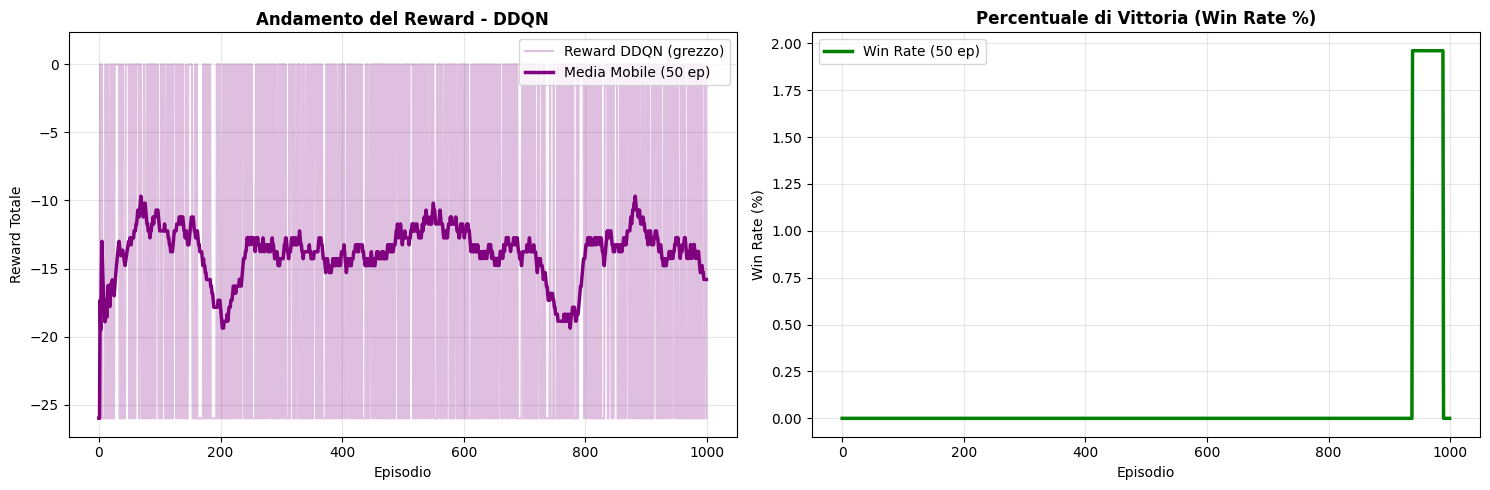

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcolo della media mobile su una finestra di 50 episodi
window = 50
smooth_ddqn_rewards = [np.mean(ddqn_rewards[max(0, i-window):i+1]) for i in range(len(ddqn_rewards))]
smooth_ddqn_wins = [np.mean(ddqn_wins[max(0, i-window):i+1]) * 100 for i in range(len(ddqn_wins))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grafico dei Reward DDQN
ax1.plot(ddqn_rewards, alpha=0.25, color='purple', label='Reward DDQN (grezzo)')
ax1.plot(smooth_ddqn_rewards, color='purple', linewidth=2.5, label=f'Media Mobile ({window} ep)')
ax1.set_title('Andamento del Reward - DDQN', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Reward Totale')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Grafico del Win Rate DDQN
ax2.plot(smooth_ddqn_wins, color='green', linewidth=2.5, label=f'Win Rate ({window} ep)')
ax2.set_title('Percentuale di Vittoria (Win Rate %)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Win Rate (%)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()